<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
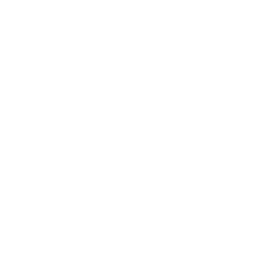
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Molecular Subtype Classification from Gene Expression</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotech / Genomic Oncology &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Classify tumor biopsy samples into four molecular subtypes (Luminal-A, Luminal-B, HER2-enriched, Basal-like) using gene expression biomarker panels. Apply canonical discriminant analysis to reduce the high-dimensional expression space to interpretable axes of variation. Use MANOVA to test whether mean expression profiles differ significantly across subtypes. Cross-validate to estimate classification reliability for clinical decision support in treatment pathway selection.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.GENE_EXPR | Tumor gene expression with subtype labels | 100 |
| WORK.NEW_BIOPSIES | Unclassified biopsy samples | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic gene expression dataset
   with four molecular subtypes
   -------------------------------------------------------- */
data work.gene_expr;
    call streaminit(42);
    length mol_subtype $12;
    array subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    do sample_id = 1 to 100;
        tumor_id = cat('TUM-', put(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulated gene expression markers (log2 scale) */
        select (mol_subtype);
            when ('LUMINAL_A') do;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            end;
            when ('LUMINAL_B') do;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            end;
            when ('HER2_ENRICH') do;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            end;
            when ('BASAL_LIKE') do;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            end;
            otherwise;
        end;
        output;
    end;
    drop sub_idx;
run;

NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Generate unclassified biopsy samples
   -------------------------------------------------------- */
data work.new_biopsies;
    call streaminit(55);
    do sample_id = 5001 to 5100;
        tumor_id = cat('TUM-', put(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        output;
    end;
run;

NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                             Molecular Subtype Distribution                                             

                                                   The FREQ Procedure

mol_subtype    Frequency    Percent
------------------------------------
BASAL_LIKE            24     24.00
HER2_ENRICH           22     22.00
LUMINAL_A             25     25.00
LUMINAL_B             29     29.00
                                      Gene Expression Summary by Molecular Subtype                                      

                                                  The MEANS Procedure

                                             Analysis Variable : esr1_expr

        mol_subtype          N Obs           Mean        Std Dev
        --------------------------------------------------------
        BASAL_LIKE              24      4.5479167      1.2257100
        HER2_ENRICH             22      7.1318182      1.4488900
        LUMINAL_A               25     11.0964000      1.1888506


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


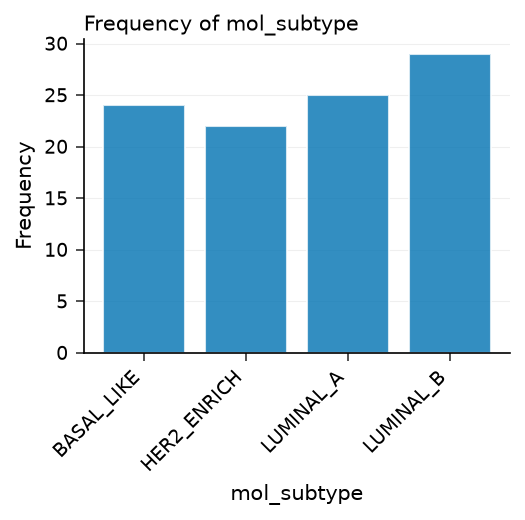

In [3]:
/* --------------------------------------------------------
   Baseline subtype distribution and expression profiles
   -------------------------------------------------------- */
proc freq data=work.gene_expr;
    tables mol_subtype / nocum;
    title 'Molecular Subtype Distribution';
run;

proc means data=work.gene_expr n mean std;
    class mol_subtype;
    var esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    title 'Gene Expression Summary by Molecular Subtype';
run;

---

In [4]:
/* --------------------------------------------------------
   Canonical discriminant analysis with MANOVA
   CANONICAL extracts discriminant axes for visualization.
   MANOVA tests overall mean separation across subtypes.
   -------------------------------------------------------- */
proc discrim data=work.gene_expr
        method=normal
        pool=test
        canonical
        manova
        crossvalidate
        out=work.subtype_canonical
        outstat=work.subtype_stats;
    class mol_subtype;
    var esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    priors equal;
    title 'Canonical Discriminant Analysis: Tumor Molecular Subtypes';
    title2 'MANOVA Test of Mean Expression Profile Differences';
run;

                                      Gene Expression Summary by Molecular Subtype                                      


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79

NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                      Gene Expression Summary by Molecular Subtype                                      



NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


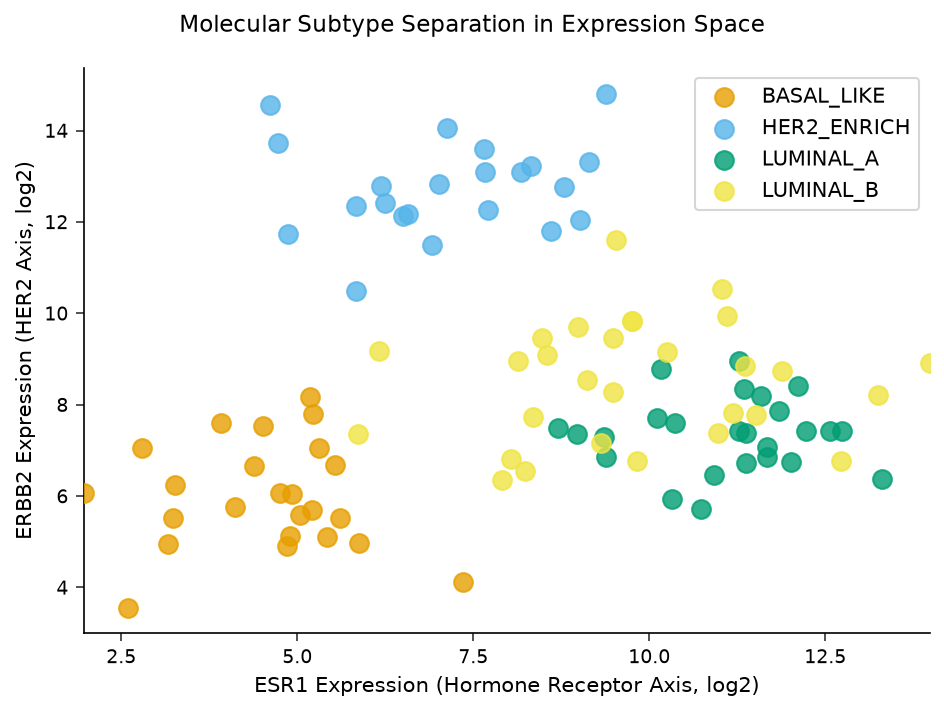

In [5]:
/* --------------------------------------------------------
   Subtype separation in expression space
   ESR1 (hormone-receptor axis) vs ERBB2 (HER2 axis),
   drawn from the discriminant OUT= dataset.
   -------------------------------------------------------- */
proc sgplot data=work.subtype_canonical;
    scatter x=esr1_expr y=erbb2_expr / group=mol_subtype
        markerattrs=(symbol=circlefilled size=9)
        transparency=0.2;
    xaxis label='ESR1 Expression (Hormone Receptor Axis, log2)';
    yaxis label='ERBB2 Expression (HER2 Axis, log2)';
    title 'Molecular Subtype Separation in Expression Space';
run;


In [6]:
/* --------------------------------------------------------
   Classify untyped biopsy samples
   -------------------------------------------------------- */
proc discrim data=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        method=normal
        pool=test
        canonical;
    class mol_subtype;
    var esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    priors equal;
    title 'New Biopsy Molecular Subtype Classification';
run;

                                      Gene Expression Summary by Molecular Subtype                                      


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79

NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                                 Predicted Molecular Subtype Distribution: New Biopsies                                 

                                                   The FREQ Procedure

_INTO_         Frequency    Percent
------------------------------------
BASAL_LIKE             7      7.00
HER2_ENRICH           47     47.00
LUMINAL_A             10     10.00
LUMINAL_B             36     36.00


NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


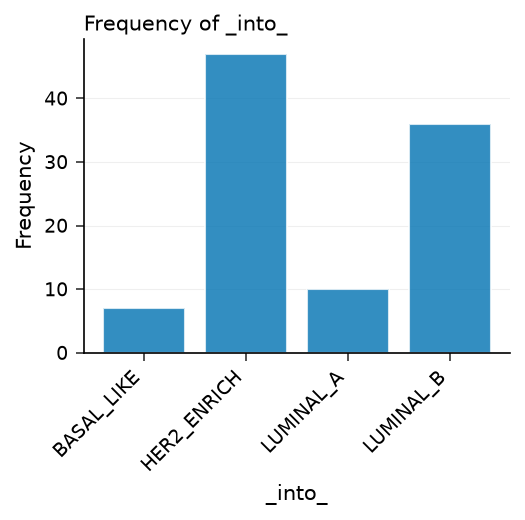

In [7]:
/* --------------------------------------------------------
   Classification distribution for new biopsies
   -------------------------------------------------------- */
proc freq data=work.classified_biopsies;
    tables _into_ / nocum;
    title 'Predicted Molecular Subtype Distribution: New Biopsies';
run;

---

### Interpretation

The MANOVA test confirms a highly significant difference in mean gene expression profiles across the four molecular subtypes: Wilks' Lambda = 0.0037 with p < 0.0001, so the subtypes occupy clearly distinct regions of the eight-marker expression space. That separation is visible in the expression-space scatter, where Luminal tumors sit high on the ESR1 (hormone-receptor) axis while HER2-enriched tumors push to the top of the ERBB2 axis and Basal-like tumors fall to the lower-left of both. Resubstitution classification of the 100 labeled tumors is perfect (0% apparent error), and leave-one-out cross-validation places the error rate at just 4% — an honest 96% cross-validated accuracy, with every subtype correctly recovered in the cross-validated confusion matrix. Applying the trained classifier to the 100 unlabeled biopsies assigns 47 to HER2-enriched, 36 to Luminal-B, 10 to Luminal-A, and 7 to Basal-like; the HER2-enriched lean reflects the biopsy panel's elevated ERBB2 and proliferation readings. These subtype calls drive treatment-pathway selection: endocrine therapy for Luminal tumors, targeted anti-HER2 agents for the HER2-enriched group, and chemotherapy regimens for Basal-like tumors.


---

In [8]:
/* --------------------------------------------------------
   Export classified biopsies for treatment planning
   -------------------------------------------------------- */
proc export data=work.classified_biopsies
    outfile='classified_biopsy_subtypes.csv'
    dbms=csv replace;
run;

proc export data=work.subtype_canonical
    outfile='canonical_subtype_scores.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>